Verifica se all'interno del dataset sono presenti per le colonne  "content" e "content_commit_sha" valori NaN oppure sono vuote e in caso affermativo, eliminare l'intera riga poichè non avere informazioni sul content non è plausibile. Eliminazione anche delle righe che hanno nella colonna "content" un testo troppo corto (es. meno di 10 parole).

In [6]:
from pathlib import Path
import pandas as pd

cwd = Path.cwd()
candidate_paths = [
    cwd / "dataset" / "dataset.csv",
    cwd.parent / "dataset" / "dataset.csv",
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("dataset.csv not found in ./dataset or ../dataset")

df = pd.read_csv(data_path)

required_cols = ["content", "content_commit_sha"]
mask_missing = df[required_cols].isna().any(axis=1)
mask_empty = df[required_cols].astype(str).apply(lambda col: col.str.strip().eq(""), axis=0)
mask_empty_any = mask_empty.any(axis=1)
df_clean = df[~(mask_missing | mask_empty_any)].copy()

word_counts = df_clean["content"].astype(str).str.split().str.len()
df_clean = df_clean[word_counts >= 10].copy()

print(f"Rows before: {len(df)}, after cleaning: {len(df_clean)}")

Rows before: 2303, after cleaning: 2179


Realizzazione del barplot per vedere la distribuzione della variabile commit_count

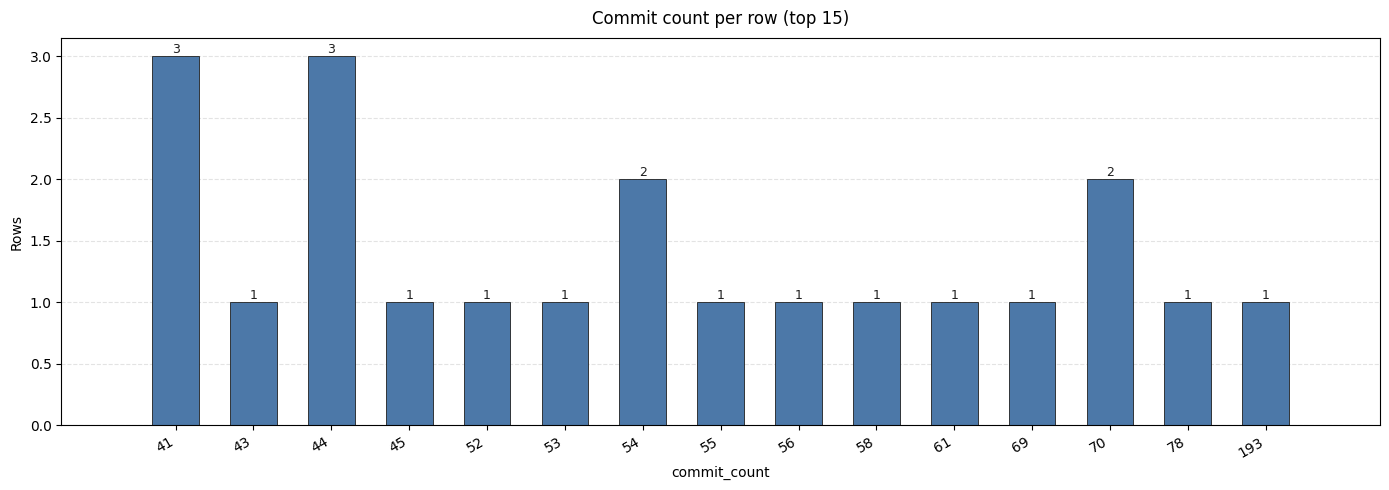

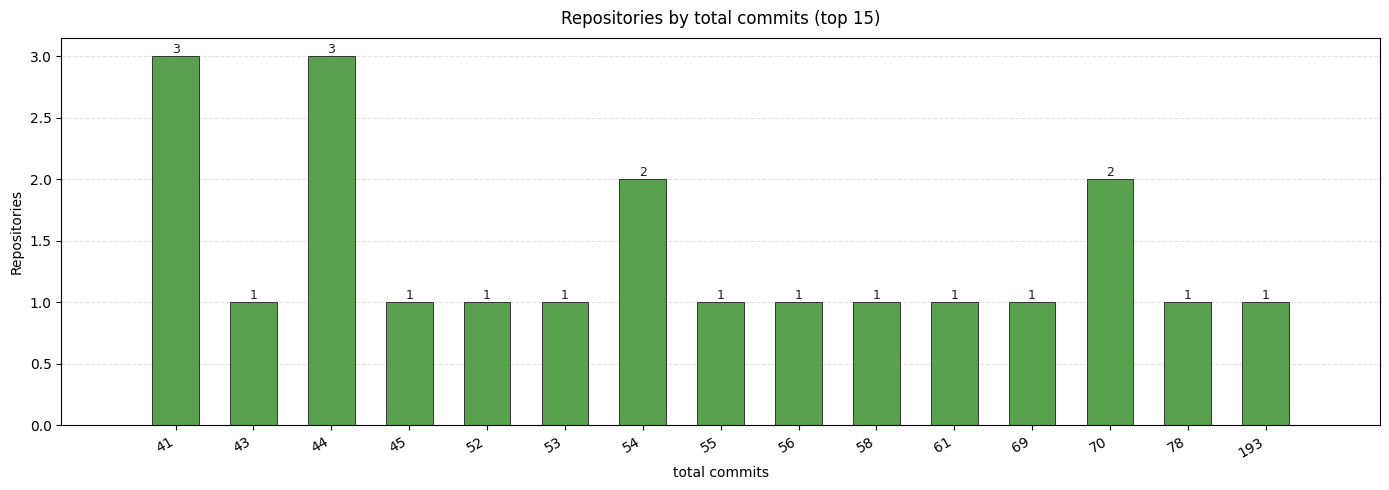

In [7]:
import matplotlib.pyplot as plt

TOP_N = 15  # show only the highest commit_count values

commit_count_num = pd.to_numeric(df_clean["commit_count"], errors="coerce")
row_counts = commit_count_num.dropna().astype(int).value_counts().sort_index()

if "repo_url" in df_clean.columns:
    repo_id = df_clean["repo_url"].astype(str)
else:
    repo_id = df_clean["repository_owner"].astype(str) + "/" + df_clean["repository_name"].astype(str)

repo_commit = (
    pd.DataFrame({"repo_id": repo_id, "commit_count": commit_count_num})
    .dropna(subset=["commit_count"])
    .groupby("repo_id")["commit_count"]
    .max()
 )
repo_counts = repo_commit.astype(int).value_counts().sort_index()

def top_by_commit(series, top_n):
    if series.empty or top_n is None or top_n <= 0:
        return series
    return series.iloc[-top_n:]

def barplot_counts(series, title, xlabel, ylabel, color):
    fig, ax = plt.subplots(figsize=(14, 5))
    x_labels = series.index.astype(int).astype(str)
    y = series.values
    positions = range(len(x_labels))
    bars = ax.bar(positions, y, color=color, edgecolor="#1f1f1f", linewidth=0.6, width=0.6)
    for rect, value in zip(bars, y):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height(),
            str(value),
            ha="center",
            va="bottom",
            fontsize=9,
            color="#1f1f1f",
            clip_on=True,
        )
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_xticks(list(positions))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")
    ax.margins(x=0.08)
    plt.tight_layout()

barplot_counts(
    top_by_commit(row_counts, TOP_N),
    f"Commit count per row (top {TOP_N})",
    "commit_count",
    "Rows",
    "#4c78a8",
)
barplot_counts(
    top_by_commit(repo_counts, TOP_N),
    f"Repositories by total commits (top {TOP_N})",
    "total commits",
    "Repositories",
    "#59a14f",
)

Nel dataset sono state eliminate tutte quelle repository che presentano un numero di commit effettuati minore di 4

In [8]:
commit_count_num = pd.to_numeric(df_clean["commit_count"], errors="coerce")
df_commit40 = df_clean[commit_count_num >= 40].copy()

print(f"Rows with commit_count >= 40: {len(df_commit40)}")

Rows with commit_count >= 40: 22


Verifico se le colonne file_path e filename sono vuote

In [9]:
cols = ["file_path", "filename"]
missing_cols = [col for col in cols if col not in df_commit40.columns]

if missing_cols:
    print(f"Missing columns: {missing_cols}")
else:
    total_rows = len(df_commit40)
    if total_rows == 0:
        print("No rows to check.")
    else:
        def is_empty(series):
            return series.isna() | series.astype(str).str.strip().eq("")

        empty_flags = df_commit40[cols].apply(is_empty)
        for col in cols:
            empty_count = int(empty_flags[col].sum())
            print(f"{col}: empty {empty_count}/{total_rows} (all empty: {bool(empty_flags[col].all())})")

        both_empty = empty_flags.all(axis=1)
        print(f"Rows with both empty: {int(both_empty.sum())}/{total_rows}")
        print(f"All rows have both empty: {bool(both_empty.all())}")

file_path: empty 0/22 (all empty: False)
filename: empty 0/22 (all empty: False)
Rows with both empty: 0/22
All rows have both empty: False


Salvataggio delle modifiche effettuate in un nuovo dataset

In [10]:
from pathlib import Path

output_path = Path(data_path).parent / "dataset_cleaned.csv"
df_commit40.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Saved: d:\Progetti\ContextWare\dataset\dataset_cleaned.csv
